
Resultados encontrados:

k = 6
  alpha=0.0 | accuracy=50.25%
  alpha=0.1 | accuracy=45.88%
  alpha=0.2 | accuracy=47.99%
  alpha=0.3 | accuracy=44.74%
  alpha=0.4 | accuracy=45.28%
  alpha=0.5 | accuracy=41.41%
  alpha=0.6 | accuracy=42.97%
  alpha=0.7 | accuracy=43.76%
  alpha=0.8 | accuracy=44.08%
  alpha=0.9 | accuracy=43.19%
  alpha=1.0 | accuracy=40.87%

k = 8
  alpha=0.0 | accuracy=47.78%
  alpha=0.1 | accuracy=43.13%
  alpha=0.2 | accuracy=46.58%
  alpha=0.3 | accuracy=42.89%
  alpha=0.4 | accuracy=45.35%
  alpha=0.5 | accuracy=41.95%
  alpha=0.6 | accuracy=41.52%
  alpha=0.7 | accuracy=43.86%
  alpha=0.8 | accuracy=44.54%
  alpha=0.9 | accuracy=44.71%
  alpha=1.0 | accuracy=42.85%

k = 10
  alpha=0.0 | accuracy=52.03%
  alpha=0.1 | accuracy=47.59%
  alpha=0.2 | accuracy=46.33%
  alpha=0.3 | accuracy=43.17%
  alpha=0.4 | accuracy=42.99%
  alpha=0.5 | accuracy=45.29%
  alpha=0.6 | accuracy=41.56%
  alpha=0.7 | accuracy=40.54%
  alpha=0.8 | accuracy=43.41%
  alpha=0.9 | accuracy=

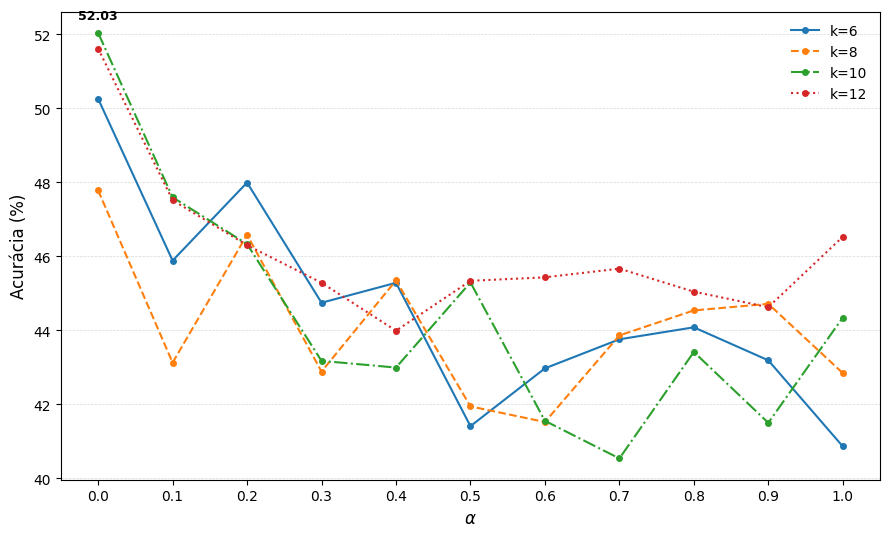


Gráfico salvo em: results_paper\sdfs_with_normal\accuracy_k_alpha.pdf


In [1]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURAÇÕES
# ============================================================

BASE_DIR = Path("results_paper/sdfs_with_normal")

K_VALUES = [6, 8, 10, 12]

# alpha-0 -> 0.0
# alpha-1 -> 0.1
# ...
# alpha-10 -> 1.0
ALPHA_DIVISOR = 10


# ============================================================
# FUNÇÕES
# ============================================================

def get_alpha_from_filename(filename):
    """
    Extrai o valor de alpha do nome do arquivo.

    Exemplo:
        alpha-0_2026-08-15_17-02-36.json  -> 0.0
        alpha-6_2026-08-15_17-37-33.json  -> 0.6
        alpha-10_2026-08-15_17-47-45.json -> 1.0
    """

    match = re.search(r"alpha-(\d+)_", filename)

    if match is None:
        raise ValueError(
            f"Não foi possível identificar alpha no arquivo: {filename}"
        )

    alpha_index = int(match.group(1))

    return alpha_index / ALPHA_DIVISOR


def calculate_mean_accuracy(json_path):
    """
    Calcula a acurácia média considerando todos os domínios
    presentes em 'scores'.
    """

    with open(json_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    accuracies = [
        domain_data["accuracy_score"]
        for domain_data in data["scores"].values()
    ]

    return np.mean(accuracies)


def load_results(base_dir, k_values):
    """
    Percorre os diretórios k-* e retorna os resultados
    organizados por k.
    """

    results = {}

    for k in k_values:

        k_dir = base_dir / f"k-{k}"

        if not k_dir.exists():
            print(f"Aviso: diretório não encontrado: {k_dir}")
            continue

        k_results = []

        for json_path in k_dir.glob("alpha-*.json"):

            alpha = get_alpha_from_filename(json_path.name)

            mean_accuracy = calculate_mean_accuracy(json_path)

            k_results.append({
                "alpha": alpha,
                "accuracy": mean_accuracy,
                "file": json_path.name
            })

        # Ordena pelos valores de alpha
        k_results.sort(key=lambda x: x["alpha"])

        results[k] = k_results

    return results


# ============================================================
# LEITURA DOS RESULTADOS
# ============================================================

results = load_results(
    base_dir=BASE_DIR,
    k_values=K_VALUES
)


# ============================================================
# MOSTRA OS VALORES NO TERMINAL
# ============================================================

print("\nResultados encontrados:\n")

for k, values in results.items():

    print(f"k = {k}")

    for item in values:
        print(
            f"  alpha={item['alpha']:.1f} | "
            f"accuracy={item['accuracy'] * 100:.2f}%"
        )

    print()


# ============================================================
# IDENTIFICA O MELHOR RESULTADO GLOBAL
# ============================================================

best_result = None

for k, values in results.items():

    for item in values:

        candidate = {
            "k": k,
            "alpha": item["alpha"],
            "accuracy": item["accuracy"]
        }

        if (
            best_result is None
            or candidate["accuracy"] > best_result["accuracy"]
        ):
            best_result = candidate


if best_result is not None:

    print("Melhor configuração:")
    print(f"k = {best_result['k']}")
    print(f"alpha = {best_result['alpha']:.1f}")
    print(f"accuracy = {best_result['accuracy'] * 100:.2f}%")


# ============================================================
# GERAÇÃO DO GRÁFICO
# ============================================================

plt.figure(figsize=(9, 5.5))


# Diferentes estilos facilitam a impressão em escala de cinza
line_styles = {
    6: "-",
    8: "--",
    10: "-.",
    12: ":"
}


for k, values in results.items():

    if len(values) == 0:
        continue

    alphas = [
        item["alpha"]
        for item in values
    ]

    accuracies = [
        item["accuracy"] * 100
        for item in values
    ]

    plt.plot(
        alphas,
        accuracies,
        marker="o",
        linestyle=line_styles.get(k, "-"),
        linewidth=1.5,
        markersize=4,
        label=f"k={k}"
    )


# ============================================================
# DESTACA O MELHOR RESULTADO
# ============================================================

if best_result is not None:

    best_alpha = best_result["alpha"]
    best_accuracy = best_result["accuracy"] * 100

    plt.annotate(
        f"{best_accuracy:.2f}",
        xy=(best_alpha, best_accuracy),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# FORMATAÇÃO
# ============================================================

plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel("Acurácia (%)", fontsize=12)

plt.xticks(
    np.arange(0.0, 1.01, 0.1)
)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.5
)

plt.legend(
    frameon=False
)

plt.tight_layout()


# ============================================================
# SALVAR FIGURA
# ============================================================

output_file = BASE_DIR / "accuracy_k_alpha.pdf"

plt.savefig(
    output_file,
    bbox_inches="tight"
)

# Opcionalmente também salva em PNG
plt.savefig(
    BASE_DIR / "accuracy_k_alpha.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nGráfico salvo em: {output_file}")

In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# CONFIGURAÇÕES
# ============================================================

BASE_DIR = Path("results_paper/sdfs_with_normal")

K_VALUES = [6, 8, 10, 12]

DOMAINS = range(1, 10)

# Conversão:
# alpha-0  -> 0.0
# alpha-1  -> 0.1
# ...
# alpha-10 -> 1.0
ALPHA_DIVISOR = 10


# ============================================================
# FUNÇÕES
# ============================================================

def get_alpha_from_filename(filename):
    """
    Extrai alpha a partir do nome do arquivo.

    Exemplos:
        alpha-0_2026-08-15_17-02-36.json  -> 0.0
        alpha-6_2026-08-15_17-37-33.json  -> 0.6
        alpha-10_2026-08-15_17-47-45.json -> 1.0
    """

    match = re.search(r"alpha-(\d+)_", filename)

    if match is None:
        raise ValueError(
            f"Não foi possível identificar alpha no arquivo: {filename}"
        )

    alpha_index = int(match.group(1))

    return alpha_index / ALPHA_DIVISOR


def get_domain_accuracy(json_path, domain):
    """
    Retorna a acurácia de um domínio específico.

    Exemplo:
        domain = 1

    retorna:

        data["scores"]["domains_1"]["accuracy_score"]
    """

    with open(json_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    domain_key = f"domains_{domain}"

    if domain_key not in data["scores"]:
        raise KeyError(
            f"{domain_key} não encontrado em {json_path}"
        )

    return data["scores"][domain_key]["accuracy_score"]


def load_results_for_domain(base_dir, k_values, domain):
    """
    Carrega todas as acurácias correspondentes a um domínio
    para diferentes valores de k e alpha.

    Estrutura retornada:

    {
        6: [
            {"alpha": 0.0, "accuracy": ...},
            {"alpha": 0.1, "accuracy": ...},
            ...
        ],
        8: [...],
        10: [...],
        12: [...]
    }
    """

    results = {}

    for k in k_values:

        k_dir = base_dir / f"k-{k}"

        if not k_dir.exists():
            print(f"Aviso: diretório não encontrado: {k_dir}")
            continue

        k_results = []

        for json_path in k_dir.glob("alpha-*.json"):

            alpha = get_alpha_from_filename(json_path.name)

            try:
                accuracy = get_domain_accuracy(
                    json_path,
                    domain
                )
            except KeyError as error:
                print(error)
                continue

            k_results.append({
                "alpha": alpha,
                "accuracy": accuracy,
                "file": json_path.name
            })

        # Ordena os resultados por alpha
        k_results.sort(key=lambda x: x["alpha"])

        results[k] = k_results

    return results


def find_best_result(results):
    """
    Identifica a combinação k/alpha com maior acurácia.
    """

    best_result = None

    for k, values in results.items():

        for item in values:

            candidate = {
                "k": k,
                "alpha": item["alpha"],
                "accuracy": item["accuracy"]
            }

            if (
                best_result is None
                or candidate["accuracy"] > best_result["accuracy"]
            ):
                best_result = candidate

    return best_result


# ============================================================
# ESTILOS DAS CURVAS
# ============================================================

# Diferentes estilos são úteis para impressão em escala de cinza
line_styles = {
    6: "-",
    8: "--",
    10: "-.",
    12: ":"
}

markers = {
    6: "o",
    8: "s",
    10: "^",
    12: "D"
}


# ============================================================
# GERA OS 9 GRÁFICOS
# ============================================================

for domain in DOMAINS:

    # --------------------------------------------------------
    # Carrega os resultados do domínio
    # --------------------------------------------------------

    results = load_results_for_domain(
        base_dir=BASE_DIR,
        k_values=K_VALUES,
        domain=domain
    )

    # --------------------------------------------------------
    # Identifica maior acurácia
    # --------------------------------------------------------

    best_result = find_best_result(results)

    if best_result is None:
        print(f"Nenhum resultado encontrado para domains_{domain}")
        continue

    print()
    print("=" * 60)
    print(f"DOMÍNIO {domain}")
    print("=" * 60)

    # Mostra valores no terminal
    for k, values in results.items():

        print(f"\nk = {k}")

        for item in values:
            print(
                f"alpha = {item['alpha']:.1f} | "
                f"accuracy = {item['accuracy'] * 100:.2f}%"
            )

    print("\nMelhor configuração:")
    print(f"k = {best_result['k']}")
    print(f"alpha = {best_result['alpha']:.1f}")
    print(
        f"accuracy = "
        f"{best_result['accuracy'] * 100:.2f}%"
    )

    # --------------------------------------------------------
    # Cria figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(9, 5.5))

    # --------------------------------------------------------
    # Plota uma curva para cada k
    # --------------------------------------------------------

    for k, values in results.items():

        if not values:
            continue

        alphas = [
            item["alpha"]
            for item in values
        ]

        accuracies = [
            item["accuracy"] * 100
            for item in values
        ]

        ax.plot(
            alphas,
            accuracies,
            marker=markers.get(k, "o"),
            linestyle=line_styles.get(k, "-"),
            linewidth=1.5,
            markersize=4,
            label=f"k={k}"
        )

    # --------------------------------------------------------
    # Destaca maior acurácia
    # --------------------------------------------------------

    best_alpha = best_result["alpha"]
    best_accuracy = best_result["accuracy"] * 100

    ax.annotate(
        f"{best_accuracy:.2f}",
        xy=(best_alpha, best_accuracy),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Formatação
    # --------------------------------------------------------

    ax.set_xlabel(
        r"$\alpha$",
        fontsize=12
    )

    ax.set_ylabel(
        "Acurácia (%)",
        fontsize=12
    )

    ax.set_xticks(
        np.arange(0.0, 1.01, 0.1)
    )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.5
    )

    ax.legend(
        frameon=False
    )

    fig.tight_layout()

    # --------------------------------------------------------
    # Salva o gráfico
    # --------------------------------------------------------

    pdf_path = (
        BASE_DIR /
        f"accuracy_domain_{domain}.pdf"
    )

    png_path = (
        BASE_DIR /
        f"accuracy_domain_{domain}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    print(f"\nGráfico salvo:")
    print(pdf_path)


print("\nTodos os 9 gráficos foram gerados.")


DOMÍNIO 1

k = 6
alpha = 0.0 | accuracy = 44.23%
alpha = 0.1 | accuracy = 44.86%
alpha = 0.2 | accuracy = 44.65%
alpha = 0.3 | accuracy = 42.35%
alpha = 0.4 | accuracy = 44.86%
alpha = 0.5 | accuracy = 45.07%
alpha = 0.6 | accuracy = 44.23%
alpha = 0.7 | accuracy = 44.44%
alpha = 0.8 | accuracy = 44.44%
alpha = 0.9 | accuracy = 44.03%
alpha = 1.0 | accuracy = 44.44%

k = 8
alpha = 0.0 | accuracy = 48.64%
alpha = 0.1 | accuracy = 44.03%
alpha = 0.2 | accuracy = 44.44%
alpha = 0.3 | accuracy = 45.49%
alpha = 0.4 | accuracy = 45.28%
alpha = 0.5 | accuracy = 45.91%
alpha = 0.6 | accuracy = 45.91%
alpha = 0.7 | accuracy = 45.49%
alpha = 0.8 | accuracy = 45.91%
alpha = 0.9 | accuracy = 45.70%
alpha = 1.0 | accuracy = 45.70%

k = 10
alpha = 0.0 | accuracy = 46.12%
alpha = 0.1 | accuracy = 45.28%
alpha = 0.2 | accuracy = 44.86%
alpha = 0.3 | accuracy = 44.86%
alpha = 0.4 | accuracy = 45.28%
alpha = 0.5 | accuracy = 45.70%
alpha = 0.6 | accuracy = 45.70%
alpha = 0.7 | accuracy = 45.70%
alpha =

In [5]:
import json
import re
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# CONFIGURAÇÕES
# ============================================================

BASE_DIR = Path("results_paper/validation_sdfs")

K_VALUES = [6, 8, 10, 12]

DOMAINS = range(1, 10)

# Conversão:
# alpha-0  -> 0.0
# alpha-1  -> 0.1
# ...
# alpha-10 -> 1.0
ALPHA_DIVISOR = 10


# ============================================================
# FUNÇÕES
# ============================================================

def get_alpha_from_filename(filename):
    """
    Extrai o valor de alpha do nome do arquivo.

    Exemplos:
        alpha-0_2026-08-15_23-51-03.json  -> 0.0
        alpha-1_2026-08-16_00-33-12.json  -> 0.1
        alpha-10_2026-08-16_05-33-06.json -> 1.0
    """

    match = re.search(r"alpha-(\d+)_", filename)

    if match is None:
        raise ValueError(
            f"Não foi possível identificar alpha em: {filename}"
        )

    alpha_index = int(match.group(1))

    return alpha_index / ALPHA_DIVISOR


def get_domain_and_accuracy(json_path):
    """
    Lê um arquivo JSON contendo apenas um domínio e retorna:

        domain
        accuracy

    Exemplo de JSON:

    "scores": {
        "domains_3": {
            "accuracy_score": 0.6256,
            ...
        }
    }

    Retorno:
        domain = 3
        accuracy = 0.6256
    """

    with open(json_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    scores = data.get("scores", {})

    if len(scores) == 0:
        raise ValueError(
            f"Nenhum domínio encontrado em {json_path}"
        )

    # Como cada arquivo possui apenas um domínio
    domain_key = next(iter(scores))

    match = re.search(r"domains_(\d+)", domain_key)

    if match is None:
        raise ValueError(
            f"Domínio não identificado em {json_path}: {domain_key}"
        )

    domain = int(match.group(1))

    accuracy = scores[domain_key]["accuracy_score"]

    return domain, accuracy


# ============================================================
# CARREGAMENTO DOS RESULTADOS
# ============================================================

def load_all_results(base_dir, k_values):
    """
    Estrutura resultante:

    results[domain][k][alpha] = soma das acurácias

    Exemplo:

    results[1][6][0.0] = ...
    results[1][6][0.1] = ...
    results[1][8][0.0] = ...
    """

    # Guarda inicialmente uma lista para permitir que vários
    # arquivos pertençam ao mesmo domínio/k/alpha.
    grouped_results = defaultdict(
        lambda: defaultdict(
            lambda: defaultdict(list)
        )
    )

    for k in k_values:

        k_dir = base_dir / f"k-{k}"

        if not k_dir.exists():
            print(f"Aviso: diretório não encontrado: {k_dir}")
            continue

        # ----------------------------------------------------
        # Percorre TODOS os arquivos JSON
        # ----------------------------------------------------

        json_files = sorted(k_dir.glob("alpha-*.json"))

        print(
            f"k={k}: {len(json_files)} arquivos encontrados."
        )

        for json_path in json_files:

            try:
                alpha = get_alpha_from_filename(
                    json_path.name
                )

                domain, accuracy = get_domain_and_accuracy(
                    json_path
                )

            except (ValueError, KeyError) as error:
                print(f"Erro em {json_path}: {error}")
                continue

            grouped_results[domain][k][alpha].append(
                accuracy
            )

    # ========================================================
    # SOMA AS ACURÁCIAS DA MESMA COMBINAÇÃO
    # domain + k + alpha
    # ========================================================

    results = defaultdict(
        lambda: defaultdict(dict)
    )

    for domain, k_data in grouped_results.items():

        for k, alpha_data in k_data.items():

            for alpha, accuracies in alpha_data.items():

                results[domain][k][alpha] = np.mean(
                    accuracies
                )

    return results


# ============================================================
# CARREGA OS DADOS
# ============================================================

results = load_all_results(
    base_dir=BASE_DIR,
    k_values=K_VALUES
)


# ============================================================
# ESTILOS DAS CURVAS
# ============================================================

line_styles = {
    6: "-",
    8: "--",
    10: "-.",
    12: ":"
}

markers = {
    6: "o",
    8: "s",
    10: "^",
    12: "D"
}


# ============================================================
# GERA UM GRÁFICO PARA CADA DOMÍNIO
# ============================================================

for domain in DOMAINS:

    if domain not in results:
        print(
            f"Nenhum resultado encontrado para o domínio {domain}."
        )
        continue

    print()
    print("=" * 60)
    print(f"DOMÍNIO {domain}")
    print("=" * 60)

    # --------------------------------------------------------
    # Procura melhor resultado do domínio
    # --------------------------------------------------------

    best_accuracy = -np.inf
    best_alpha = None
    best_k = None

    for k in K_VALUES:

        if k not in results[domain]:
            continue

        for alpha, accuracy in results[domain][k].items():

            print(
                f"k={k:2d} | "
                f"alpha={alpha:.1f} | "
                f"accuracy={accuracy * 100:.2f}%"
            )

            if accuracy > best_accuracy:

                best_accuracy = accuracy
                best_alpha = alpha
                best_k = k

    print()
    print("Melhor configuração:")
    print(f"k = {best_k}")
    print(f"alpha = {best_alpha:.1f}")
    print(
        f"accuracy = {best_accuracy * 100:.2f}%"
    )

    # ========================================================
    # CRIA O GRÁFICO
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(9, 5.5)
    )

    # --------------------------------------------------------
    # Uma curva para cada k
    # --------------------------------------------------------

    for k in K_VALUES:

        if k not in results[domain]:
            continue

        alpha_data = results[domain][k]

        # Ordena alpha
        alphas = sorted(alpha_data.keys())

        accuracies = [
            alpha_data[alpha] * 100
            for alpha in alphas
        ]

        ax.plot(
            alphas,
            accuracies,
            marker=markers.get(k, "o"),
            linestyle=line_styles.get(k, "-"),
            linewidth=1.5,
            markersize=4,
            label=f"k={k}"
        )

    # ========================================================
    # DESTACA MAIOR ACURÁCIA
    # ========================================================

    ax.annotate(
        f"{best_accuracy * 100:.2f}",
        xy=(
            best_alpha,
            best_accuracy * 100
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

    # ========================================================
    # FORMATAÇÃO
    # ========================================================

    ax.set_xlabel(
        r"$\alpha$",
        fontsize=12
    )

    ax.set_ylabel(
        "Acurácia (%)",
        fontsize=12
    )

    ax.set_xticks(
        np.arange(0.0, 1.01, 0.1)
    )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.5
    )

    ax.legend(
        frameon=False
    )

    fig.tight_layout()

    # ========================================================
    # SALVA
    # ========================================================

    pdf_path = (
        BASE_DIR /
        f"accuracy_domain_{domain}.pdf"
    )

    png_path = (
        BASE_DIR /
        f"accuracy_domain_{domain}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    print(f"Gráfico salvo em: {pdf_path}")


print()
print("Todos os gráficos foram gerados.")

k=6: 110 arquivos encontrados.
k=8: 110 arquivos encontrados.
k=10: 110 arquivos encontrados.
k=12: 110 arquivos encontrados.

DOMÍNIO 1
k= 6 | alpha=0.0 | accuracy=55.31%
k= 6 | alpha=1.0 | accuracy=53.38%
k= 6 | alpha=0.1 | accuracy=53.60%
k= 6 | alpha=0.2 | accuracy=54.13%
k= 6 | alpha=0.3 | accuracy=51.70%
k= 6 | alpha=0.4 | accuracy=51.76%
k= 6 | alpha=0.5 | accuracy=51.84%
k= 6 | alpha=0.6 | accuracy=52.23%
k= 6 | alpha=0.7 | accuracy=51.79%
k= 6 | alpha=0.8 | accuracy=53.10%
k= 6 | alpha=0.9 | accuracy=53.35%
k= 8 | alpha=0.0 | accuracy=49.89%
k= 8 | alpha=1.0 | accuracy=55.25%
k= 8 | alpha=0.1 | accuracy=49.53%
k= 8 | alpha=0.2 | accuracy=55.84%
k= 8 | alpha=0.3 | accuracy=55.78%
k= 8 | alpha=0.4 | accuracy=56.15%
k= 8 | alpha=0.5 | accuracy=57.54%
k= 8 | alpha=0.6 | accuracy=57.32%
k= 8 | alpha=0.7 | accuracy=57.37%
k= 8 | alpha=0.8 | accuracy=58.04%
k= 8 | alpha=0.9 | accuracy=57.32%
k=10 | alpha=0.0 | accuracy=30.11%
k=10 | alpha=1.0 | accuracy=56.06%
k=10 | alpha=0.1 | accu

In [3]:
from cwru_loader import load_cwru

data = load_cwru(
    data_dir="raw_data/cwru",
    config_path="dataset\\cwru\\config.csv",
    sensor="DE",
    segment_length=2048,
    overlap=0.0,
    sample_rate=48000,

    # somente Inner Race
    conditions=("Inner Race",),

    # severidades que serão comparadas
    severities=(0.007, 0.014, 0.021),

    # condições de carga
    loads=(0, 1, 2, 3),

    # falha no Drive End
    faulty_bearing="Drive End",

    # irrelevante para Inner Race
    outer_race_position=None,
)

X = data.X
fault_class = data.fault_class
severity = data.severity
load = data.load

In [ ]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


# ============================================================
# 1. WPD - sua implementação
# ============================================================

def Energy(coeffs, k):
    return np.sqrt(np.sum(np.array(coeffs[-k]) ** 2)) / len(coeffs[-k])


def getEnergy(wp):
    coefs = np.asarray([n.data for n in wp.get_leaf_nodes(True)])
    return np.asarray([Energy(coefs, i) for i in range(2 ** wp.maxlevel)])


def extract_features(X, wavelet='db4', mode='symmetric', maxlevel=4):
    wp = [
        pywt.WaveletPacket(
            data=x,
            wavelet=wavelet,
            mode=mode,
            maxlevel=maxlevel
        )
        for x in X
    ]

    features = np.array([getEnergy(wp_i) for wp_i in wp])

    return features


def wavelist(kind='discrete'):
    return pywt.wavelist(kind=kind)


class WaveletPackage(BaseEstimator, TransformerMixin):

    def __init__(self, wavelet='db4', mode='symmetric', maxlevel=8):
        super().__init__()
        self.wavelet = wavelet
        self.mode = mode
        self.maxlevel = maxlevel

    def transform_channels_to_features(self, X, extract_features):
        n_channels = X.shape[-1]

        features = []

        for i in range(n_channels):
            channel_features = extract_features(X[:, :, i])
            features.append(channel_features)

        features = np.concatenate(features, axis=1)

        return features

    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X, y=None):

        def wavelets(X):
            return extract_features(
                X,
                wavelet=self.wavelet,
                mode=self.mode,
                maxlevel=self.maxlevel
            )

        return self.transform_channels_to_features(
            X,
            extract_features=wavelets
        )


# ============================================================
# 2. MMD COM KERNEL RBF
# ============================================================

def rbf_kernel(X, Y, sigma):
    """
    Calcula a matriz de kernel RBF entre X e Y.
    """

    distances = pairwise_distances(X, Y, metric='sqeuclidean')

    K = np.exp(
        -distances / (2.0 * sigma ** 2)
    )

    return K


def estimate_sigma(X):
    """
    Estima sigma pela mediana das distâncias euclidianas
    entre as amostras.
    """

    distances = pairwise_distances(X, metric='euclidean')

    # remove diagonal e valores nulos
    distances = distances[
        np.triu_indices_from(distances, k=1)
    ]

    distances = distances[distances > 0]

    if len(distances) == 0:
        return 1.0

    sigma = np.median(distances)

    if sigma <= 0:
        sigma = 1.0

    return sigma


def mmd_rbf(X, Y, sigma):
    """
    MMD² utilizando kernel RBF.

    Implementação baseada na estimativa empírica enviesada,
    adequada para visualização comparativa entre domínios.
    """

    Kxx = rbf_kernel(X, X, sigma)
    Kyy = rbf_kernel(Y, Y, sigma)
    Kxy = rbf_kernel(X, Y, sigma)

    mmd2 = (
        np.mean(Kxx)
        + np.mean(Kyy)
        - 2.0 * np.mean(Kxy)
    )

    # pequenos valores negativos podem aparecer por erro numérico
    return max(float(mmd2), 0.0)


# ============================================================
# 3. CRIAÇÃO DOS DOMÍNIOS
# ============================================================

def build_domains(features, severity, load, fault_class=None):
    """
    Organiza as amostras por severidade e carga.

    Parameters
    ----------
    features : ndarray
        Matriz [n_amostras, n_features].

    severity : array-like
        Severidade de cada amostra.
        Exemplo:
        ["0.007", "0.007", "0.014", ...]

    load : array-like
        Carga de cada amostra.
        Exemplo:
        [0, 1, 2, 3, ...]

    fault_class : array-like ou None
        Classe da falha.
        Exemplo:
        ["IR", "IR", "OR", ...].

    Returns
    -------
    dict
        Dicionário no formato:
        domains[(classe, severidade, carga)] = features
    """

    severity = np.asarray(severity)
    load = np.asarray(load)

    if fault_class is None:
        fault_class = np.repeat("ALL", len(features))

    fault_class = np.asarray(fault_class)

    domains = {}

    classes = np.unique(fault_class)

    for cls in classes:

        cls_mask = fault_class == cls

        severities = np.unique(severity[cls_mask])

        for sev in severities:

            loads = np.unique(
                load[
                    cls_mask &
                    (severity == sev)
                ]
            )

            for ld in loads:

                mask = (
                    (fault_class == cls) &
                    (severity == sev) &
                    (load == ld)
                )

                if np.sum(mask) > 0:
                    domains[(cls, sev, ld)] = features[mask]

    return domains


# ============================================================
# 4. MATRIZ MMD PARA UMA CLASSE
# ============================================================

def compute_mmd_matrix(
    domains,
    selected_class,
    severities=("0.007", "0.014", "0.021"),
    loads=(0, 1, 2, 3),
    sigma=None
):
    """
    Calcula a matriz MMD 12x12 para uma determinada classe.
    """

    domain_keys = []

    for sev in severities:
        for ld in loads:
            key = (selected_class, sev, ld)

            if key not in domains:
                raise ValueError(
                    f"Domínio não encontrado: {key}"
                )

            domain_keys.append(key)

    # junta todas as amostras para estimar um sigma global
    all_features = np.vstack([
        domains[key]
        for key in domain_keys
    ])

    if sigma is None:
        sigma = estimate_sigma(all_features)

    n_domains = len(domain_keys)

    matrix = np.zeros(
        (n_domains, n_domains)
    )

    for i in range(n_domains):

        X = domains[domain_keys[i]]

        for j in range(i + 1, n_domains):

            Y = domains[domain_keys[j]]

            value = mmd_rbf(
                X,
                Y,
                sigma=sigma
            )

            matrix[i, j] = value
            matrix[j, i] = value

    return matrix, domain_keys, sigma


# ============================================================
# 5. AGRUPAR DISTÂNCIAS POR FATOR
# ============================================================

def extract_factor_distances(
    matrix,
    domain_keys
):
    """
    Separa as distâncias em:

    1. mudança de carga:
       mesma severidade, cargas diferentes;

    2. mudança de severidade:
       mesma carga, severidades diferentes.
    """

    load_change = []
    severity_change = []

    rows = []

    n = len(domain_keys)

    for i in range(n):

        cls_i, sev_i, load_i = domain_keys[i]

        for j in range(i + 1, n):

            cls_j, sev_j, load_j = domain_keys[j]

            distance = matrix[i, j]

            # mesma severidade, carga diferente
            if (
                sev_i == sev_j
                and load_i != load_j
            ):

                load_change.append(distance)

                rows.append({
                    "tipo": "Carga",
                    "distancia": distance,
                    "dominio_1": domain_keys[i],
                    "dominio_2": domain_keys[j]
                })

            # mesma carga, severidade diferente
            elif (
                load_i == load_j
                and sev_i != sev_j
            ):

                severity_change.append(distance)

                rows.append({
                    "tipo": "Severidade",
                    "distancia": distance,
                    "dominio_1": domain_keys[i],
                    "dominio_2": domain_keys[j]
                })

    return (
        np.asarray(load_change),
        np.asarray(severity_change),
        pd.DataFrame(rows)
    )


# ============================================================
# 6. HEATMAP
# ============================================================

def plot_mmd_matrix(
    matrix,
    domain_keys,
    selected_class,
    save_path=None
):
    labels = [
        f"{sev}\n{load} hp"
        for _, sev, load in domain_keys
    ]

    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    im = ax.imshow(matrix)

    ax.set_xticks(
        np.arange(len(labels))
    )

    ax.set_yticks(
        np.arange(len(labels))
    )

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(labels)

    ax.set_xlabel("Domínio")
    ax.set_ylabel("Domínio")

    ax.set_title(
        f"Discrepância entre domínios - {selected_class}"
    )

    # separadores entre severidades
    for position in [3.5, 7.5]:
        ax.axhline(
            position,
            linewidth=1.5
        )
        ax.axvline(
            position,
            linewidth=1.5
        )

    cbar = fig.colorbar(
        im,
        ax=ax
    )

    cbar.set_label(r"MMD$^2$")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# ============================================================
# 7. BOXPLOT
# ============================================================

def plot_factor_comparison(
    load_change,
    severity_change,
    save_path=None
):
    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    ax.boxplot(
        [
            load_change,
            severity_change
        ],
        tick_labels=[
            "Mudança de carga",
            "Mudança de severidade"
        ],
        showmeans=True
    )

    ax.set_ylabel(r"MMD$^2$")

    ax.set_title(
        "Discrepância entre domínios"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# ============================================================
# 8. EXEMPLO DE EXECUÇÃO
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # SUBSTITUA ESTES DADOS PELOS SEUS
    # --------------------------------------------------------
    #
    # X.shape esperado:
    #
    # [n_amostras, comprimento_segmento, n_canais]
    #
    # Exemplo:
    #
    # X.shape = (5000, 2048, 1)
    #
    # severity.shape = (5000,)
    # load.shape     = (5000,)
    # fault_class.shape = (5000,)
    #
    # --------------------------------------------------------

    # Exemplo:
    #
    # X = ...
    # severity = ...
    # load = ...
    # fault_class = ...

    # --------------------------------------------------------
    # EXTRAÇÃO WPD
    # --------------------------------------------------------

    wpd = WaveletPackage(
        wavelet="db4",
        mode="symmetric",
        maxlevel=8
    )

    features = wpd.fit_transform(X)

    # --------------------------------------------------------
    # NORMALIZAÇÃO
    # --------------------------------------------------------

    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # --------------------------------------------------------
    # CRIAÇÃO DOS DOMÍNIOS
    # --------------------------------------------------------

    domains = build_domains(
        features=features_scaled,
        severity=severity,
        load=load,
        fault_class=fault_class
    )

    # --------------------------------------------------------
    # EXEMPLO: INNER RACE
    # --------------------------------------------------------

    selected_class = "IR"

    matrix, domain_keys, sigma = compute_mmd_matrix(
        domains=domains,
        selected_class=selected_class,
        severities=("0.007", "0.014", "0.021"),
        loads=(0, 1, 2, 3)
    )

    print(
        f"Sigma utilizado: {sigma:.6f}"
    )

    # --------------------------------------------------------
    # MATRIZ
    # --------------------------------------------------------

    plot_mmd_matrix(
        matrix,
        domain_keys,
        selected_class=selected_class,
        save_path="mmd_matrix_IR.pdf"
    )

    # --------------------------------------------------------
    # CARGA VS SEVERIDADE
    # --------------------------------------------------------

    load_distances, severity_distances, df = \
        extract_factor_distances(
            matrix,
            domain_keys
        )

    print("\nMudança de carga:")
    print(
        f"Média = {load_distances.mean():.6f}"
    )

    print(
        f"Mediana = {np.median(load_distances):.6f}"
    )

    print("\nMudança de severidade:")
    print(
        f"Média = {severity_distances.mean():.6f}"
    )

    print(
        f"Mediana = {np.median(severity_distances):.6f}"
    )

    print("\nComparações individuais:")
    print(df)

    plot_factor_comparison(
        load_distances,
        severity_distances,
        save_path="mmd_carga_vs_severidade.pdf"
    )

ValueError: Domínio não encontrado: ('IR', '0.007', 1)

In [ ]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURAÇÕES
# ============================================================

JSON_PATH = "results_paper\inspired_without_normal.json"

# Se quiser definir manualmente os nomes das classes, use, por exemplo:
# CLASS_NAMES = ["IR", "OR", "B"]
#
# Se deixar como None, o código criará:
# Classe 0, Classe 1, Classe 2, ...
CLASS_NAMES = None


# ============================================================
# FUNÇÃO PARA CONVERTER A MATRIZ DE CONFUSÃO
# ============================================================

def parse_confusion_matrix(matrix_string):
    """
    Converte uma matriz armazenada como string, por exemplo:

    '[[ 242  142 1282]
      [   0    0 1660]
      [   0    1 1662]]'

    para um numpy.ndarray.
    """

    # Remove os colchetes externos
    content = matrix_string.strip()

    # Encontra cada linha da matriz
    rows = re.findall(r'\[([^\[\]]+)\]', content)

    matrix = []

    for row in rows:
        # Extrai números inteiros da linha
        values = [int(x) for x in re.findall(r'-?\d+', row)]

        if values:
            matrix.append(values)

    return np.array(matrix, dtype=int)


# ============================================================
# LEITURA DO JSON
# ============================================================

with open(JSON_PATH, "r", encoding="utf-8") as file:
    data = json.load(file)


scores = data["scores"]

accuracies = []
f1_macros = []
confusion_matrices = []
fold_names = []


for fold_name, fold_data in scores.items():

    fold_names.append(fold_name)

    accuracies.append(
        fold_data["accuracy_score"]
    )

    f1_macros.append(
        fold_data["f1_macro"]
    )

    confusion_matrix = parse_confusion_matrix(
        fold_data["confusion_matrix"]
    )

    confusion_matrices.append(confusion_matrix)


accuracies = np.array(accuracies)
f1_macros = np.array(f1_macros)


# ============================================================
# VERIFICAÇÃO DAS MATRIZES
# ============================================================

matrix_shapes = [cm.shape for cm in confusion_matrices]

if len(set(matrix_shapes)) != 1:
    raise ValueError(
        f"As matrizes de confusão possuem dimensões diferentes: {matrix_shapes}"
    )


n_classes = confusion_matrices[0].shape[0]


if CLASS_NAMES is None:
    class_names = [
        f"Classe {i}"
        for i in range(n_classes)
    ]
else:
    if len(CLASS_NAMES) != n_classes:
        raise ValueError(
            f"Foram encontradas {n_classes} classes, "
            f"mas CLASS_NAMES possui {len(CLASS_NAMES)} nomes."
        )

    class_names = CLASS_NAMES


# ============================================================
# MÉDIA E DESVIO-PADRÃO
# ============================================================

accuracy_mean = accuracies.mean()

# ddof=1 -> desvio-padrão amostral
accuracy_std = (
    accuracies.std(ddof=1)
    if len(accuracies) > 1
    else 0
)

f1_mean = f1_macros.mean()

f1_std = (
    f1_macros.std(ddof=1)
    if len(f1_macros) > 1
    else 0
)


print("=" * 60)
print("RESULTADOS GERAIS")
print("=" * 60)

print(f"Experimento: {data.get('experiment_name', 'Não informado')}")
print(f"Número de folds: {len(scores)}")

print()

print(
    f"Acurácia: "
    f"{accuracy_mean * 100:.2f} ± {accuracy_std * 100:.2f}%"
)

print(
    f"F1-macro: "
    f"{f1_mean * 100:.2f} ± {f1_std * 100:.2f}%"
)


# ============================================================
# RESULTADOS INDIVIDUAIS DOS FOLDS
# ============================================================

fold_results = pd.DataFrame({
    "Fold": fold_names,
    "Acurácia (%)": accuracies * 100,
    "F1-macro (%)": f1_macros * 100
})

print("\nResultados por fold:")
display(fold_results.round(2))


# ============================================================
# MATRIZ DE CONFUSÃO AGREGADA
# ============================================================

# Soma as matrizes de todos os folds
confusion_matrix_total = np.sum(
    confusion_matrices,
    axis=0
)


confusion_df = pd.DataFrame(
    confusion_matrix_total,
    index=[f"Real: {name}" for name in class_names],
    columns=[f"Predito: {name}" for name in class_names]
)


print("\nMatriz de confusão agregada:")
display(confusion_df)


# ============================================================
# MATRIZ DE CONFUSÃO NORMALIZADA
# ============================================================

row_sums = confusion_matrix_total.sum(
    axis=1,
    keepdims=True
)

confusion_matrix_normalized = np.divide(
    confusion_matrix_total,
    row_sums,
    out=np.zeros_like(
        confusion_matrix_total,
        dtype=float
    ),
    where=row_sums != 0
)


confusion_normalized_df = pd.DataFrame(
    confusion_matrix_normalized * 100,
    index=[f"Real: {name}" for name in class_names],
    columns=[f"Predito: {name}" for name in class_names]
)


print("\nMatriz de confusão normalizada por classe (%):")
display(confusion_normalized_df.round(2))


# ============================================================
# ACURÁCIA POR CLASSE
# ============================================================

class_total = confusion_matrix_total.sum(axis=1)

class_correct = np.diag(confusion_matrix_total)

class_accuracy = np.divide(
    class_correct,
    class_total,
    out=np.zeros_like(
        class_correct,
        dtype=float
    ),
    where=class_total != 0
)


class_results = pd.DataFrame({
    "Classe": class_names,
    "Amostras": class_total,
    "Acertos": class_correct,
    "Acurácia (%)": class_accuracy * 100
})


print("\nAcurácia por classe:")
display(class_results.round(2))


# ============================================================
# GRÁFICO DA MATRIZ DE CONFUSÃO
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    confusion_matrix_normalized * 100
)

ax.set_xticks(
    np.arange(n_classes),
    labels=class_names
)

ax.set_yticks(
    np.arange(n_classes),
    labels=class_names
)

ax.set_xlabel("Classe predita")
ax.set_ylabel("Classe real")

ax.set_title(
    "Matriz de confusão normalizada"
)

plt.colorbar(
    image,
    ax=ax,
    label="Percentual (%)"
)


# Adiciona os valores dentro das células
for i in range(n_classes):
    for j in range(n_classes):

        value = confusion_matrix_normalized[i, j] * 100

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )


plt.tight_layout()
plt.show()


# ============================================================
# GRÁFICO DE ACURÁCIA POR CLASSE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    class_names,
    class_accuracy * 100
)

ax.set_ylabel("Acurácia (%)")

ax.set_xlabel("Classe")

ax.set_title(
    "Acurácia por classe"
)

ax.set_ylim(0, 105)

ax.axhline(
    accuracy_mean * 100,
    linestyle="--",
    label=f"Acurácia média dos folds ({accuracy_mean * 100:.2f}%)"
)


# Valor sobre cada barra
for bar, accuracy in zip(
    bars,
    class_accuracy * 100
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center",
        va="bottom"
    )


ax.legend()

plt.tight_layout()
plt.show()

# Calculo média acurácia global

## Com a classe Normal

In [21]:
import json
import glob
import os
import numpy as np


RESULTS_DIR = "results_paper\dinov2\sehri_et_al_proprosed_setup_normal"
OUTPUT_FILE = os.path.join(RESULTS_DIR, "compiled.json")


def compile_results(results_dir):
    json_files = glob.glob(os.path.join(results_dir, "*.json"))

    # Evita ler o próprio arquivo compilado
    json_files = [
        file for file in json_files
        if os.path.basename(file) != "compiled.json"
    ]

    folds = {}

    for file in json_files:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        for fold_name, metrics in data["scores"].items():

            if fold_name not in folds:
                folds[fold_name] = {
                    "accuracy_score": [],
                    "f1_macro": []
                }

            folds[fold_name]["accuracy_score"].append(
                metrics["accuracy_score"]
            )

            folds[fold_name]["f1_macro"].append(
                metrics["f1_macro"]
            )

    compiled = {
        "number_of_experiments": len(json_files),
        "scores": {}
    }

    # Armazena as médias de cada fold para calcular a média global
    fold_accuracy_means = []
    fold_f1_means = []

    for fold_name in sorted(folds):

        accuracy = np.array(
            folds[fold_name]["accuracy_score"],
            dtype=float
        )

        f1_macro = np.array(
            folds[fold_name]["f1_macro"],
            dtype=float
        )

        accuracy_mean = np.mean(accuracy)
        f1_mean = np.mean(f1_macro)

        compiled["scores"][fold_name] = {
            "accuracy_mean": float(accuracy_mean),
            "accuracy_std": float(np.std(accuracy)),
            "f1_macro_mean": float(f1_mean),
            "f1_macro_std": float(np.std(f1_macro))
        }

        fold_accuracy_means.append(accuracy_mean)
        fold_f1_means.append(f1_mean)

    # Média global entre todas as folds
    fold_accuracy_means = np.array(fold_accuracy_means)
    fold_f1_means = np.array(fold_f1_means)

    compiled["global"] = {
        "accuracy_mean": float(np.mean(fold_accuracy_means)),
        "accuracy_std": float(np.std(fold_accuracy_means)),
        "f1_macro_mean": float(np.mean(fold_f1_means)),
        "f1_macro_std": float(np.std(fold_f1_means))
    }

    return compiled


compiled = compile_results(RESULTS_DIR)

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(compiled, f, indent=4)

print(f"Arquivo criado: {OUTPUT_FILE}")

print(
    f"Accuracy global: "
    f"{compiled['global']['accuracy_mean']:.4f} ± "
    f"{compiled['global']['accuracy_std']:.4f}"
)

print(
    f"F1-macro global: "
    f"{compiled['global']['f1_macro_mean']:.4f} ± "
    f"{compiled['global']['f1_macro_std']:.4f}"
)

Arquivo criado: results_paper\dinov2\sehri_et_al_proprosed_setup_normal\compiled.json
Accuracy global: 0.5761 ± 0.1414
F1-macro global: 0.5665 ± 0.1462


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\adriano\AppData\Local\Temp\ipykernel_30940\3700336079.py:7: SyntaxWarning: invalid escape sequence '\d'
  RESULTS_DIR = "results_paper\dinov2\sehri_et_al_proprosed_setup_normal"


## Sem a classe Normal

In [23]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# ARQUIVOS
# ============================================================

DINO_RAW = "results_paper/dinov2/sehri_et_al_proposed_setup/result_2026-06-19_19-43-43.json"
DINO_COMPILED = "results_paper/dinov2/sehri_et_al_proposed_setup/compiled_results.json"

SDFS_RAW = "results_paper/sdfs/sehri_et_al_proposed_setup/result_2026-06-20_00-04-22.json"
SDFS_COMPILED = "results_paper/sdfs/sehri_et_al_proposed_setup/compiled_results.json"

OUTPUT_DIR = Path("results_paper/figs/sehri_proposed_sem_normal")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# ORDEM DAS CLASSES
# ============================================================

# IMPORTANTE:
# coloque aqui exatamente a ordem utilizada para gerar
# a confusion_matrix no seu experimento.
#
# Exemplo:
CLASS_LABELS = ["B", "IR", "OR"]


# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def fold_sort_key(name):
    nums = re.findall(r"\d+", name)
    return tuple(int(n) for n in nums)


def parse_confusion_matrix(matrix_string):
    rows = re.findall(r"\[([^\[\]]+)\]", matrix_string)

    matrix = []

    for row in rows:
        matrix.append(
            np.fromstring(row, sep=" ", dtype=float)
        )

    return np.vstack(matrix)


def normalize_confusion_matrix(cm):
    row_sum = cm.sum(axis=1, keepdims=True)

    return np.divide(
        cm,
        row_sum,
        out=np.zeros_like(cm, dtype=float),
        where=row_sum != 0
    ) * 100


# ============================================================
# MATRIZES DE CONFUSÃO
# ============================================================

def save_confusion_matrices(json_path, model_name):

    data = load_json(json_path)

    folds = sorted(
        data["scores"].keys(),
        key=fold_sort_key
    )

    for fold in folds:

        cm = parse_confusion_matrix(
            data["scores"][fold]["confusion_matrix"]
        )

        cm = normalize_confusion_matrix(cm)

        fig, ax = plt.subplots(figsize=(5, 4.5))

        im = ax.imshow(
            cm,
            vmin=0,
            vmax=100
        )

        ax.set_xticks(np.arange(len(CLASS_LABELS)))
        ax.set_yticks(np.arange(len(CLASS_LABELS)))

        ax.set_xticklabels(CLASS_LABELS)
        ax.set_yticklabels(CLASS_LABELS)

        ax.set_xlabel("Classe predita")
        ax.set_ylabel("Classe real")

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):

                ax.text(
                    j,
                    i,
                    f"{cm[i, j]:.1f}",
                    ha="center",
                    va="center",
                    fontsize=9
                )

        fig.colorbar(
            im,
            ax=ax,
            label="Percentual (%)"
        )

        fig.tight_layout()

        path = (
            OUTPUT_DIR /
            f"confusion_{model_name}_{fold}.png"
        )

        fig.savefig(
            path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.close(fig)

        print("Gerado:", path)


# ============================================================
# OBTÉM MÉTRICAS DOS COMPILADOS
# ============================================================

def get_compiled_values(path, metric):

    data = load_json(path)

    # DINOv2
    if "domains" in data:

        folds_data = data["domains"]

        values = [
            folds_data[fold][metric]["mean"] * 100
            for fold in sorted(
                folds_data.keys(),
                key=fold_sort_key
            )
        ]

    # WPD + SDFS + RF
    elif "scores" in data:

        folds_data = data["scores"]

        values = [
            folds_data[fold][metric]["mean"] * 100
            for fold in sorted(
                folds_data.keys(),
                key=fold_sort_key
            )
        ]

    else:
        raise ValueError(
            f"Formato não reconhecido em {path}"
        )

    return np.array(values)


# ============================================================
# BOXPLOT
# ============================================================

def save_boxplot(metric, ylabel, filename):

    dino = get_compiled_values(
        DINO_COMPILED,
        metric
    )

    sdfs = get_compiled_values(
        SDFS_COMPILED,
        metric
    )

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.boxplot(
        [dino, sdfs],
        tick_labels=[
            "DINOv2",
            "WPD + SDFS + RF"
        ]
    )

    # Mostra também cada fold individualmente
    for position, values in enumerate(
        [dino, sdfs],
        start=1
    ):
        x = np.full(
            len(values),
            position,
            dtype=float
        )

        ax.scatter(
            x,
            values,
            s=25
        )

    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 100)

    fig.tight_layout()

    path = OUTPUT_DIR / filename

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("Gerado:", path)


# ============================================================
# EXECUÇÃO
# ============================================================

if __name__ == "__main__":

    save_confusion_matrices(
        DINO_RAW,
        "dinov2"
    )

    save_confusion_matrices(
        SDFS_RAW,
        "sdfs"
    )

    save_boxplot(
        "accuracy_score",
        "Acurácia (%)",
        "boxplot_accuracy.png"
    )

    save_boxplot(
        "f1_macro",
        "F1-macro (%)",
        "boxplot_f1_macro.png"
    )

    print("\nTodas as figuras foram geradas.")

Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_dinov2_fold_0_0.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_dinov2_fold_0_1.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_dinov2_fold_0_2.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_dinov2_fold_1_0.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_dinov2_fold_1_1.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_dinov2_fold_1_2.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_dinov2_fold_2_0.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_dinov2_fold_2_1.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_dinov2_fold_2_2.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_sdfs_fold_0_0.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_sdfs_fold_0_1.png
Gerado: results_paper\figs\sehri_proposed_sem_normal\confusion_sdfs_fold_0_2.png
Gerado: re

## Gráfico comparando protocolo com a classe normal e sem a classe Normal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# CONFIGURAÇÃO
# ============================================================

OUTPUT_DIR = Path("figs/sehri_proposed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

configuracoes = ["Com Normal", "Sem Normal"]
x = np.arange(len(configuracoes))


# ============================================================
# RESULTADOS
# ============================================================

resultados = {
    "accuracy": {
        "DINOv2": {
            "mean": [56.79, 48.06],
            "std":  [13.91, 15.86]
        },
        "WPD + SCED + RF": {
            "mean": [47.33, 39.90],
            "std":  [18.00, 17.64]
        }
    },

    "f1": {
        "DINOv2": {
            "mean": [56.22, 39.25],
            "std":  [14.09, 17.13]
        },
        "WPD + SCED + RF": {
            "mean": [47.74, 34.00],
            "std":  [19.93, 17.89]
        }
    }
}


# ============================================================
# FUNÇÃO PARA GERAR O GRÁFICO
# ============================================================

def gerar_grafico(metrica, ylabel, filename):

    fig, ax = plt.subplots(figsize=(6.5, 5))

    # --------------------------------------------------------
    # DINOv2
    # --------------------------------------------------------

    ax.errorbar(
        x,
        resultados[metrica]["DINOv2"]["mean"],
        yerr=resultados[metrica]["DINOv2"]["std"],
        marker="o",
        markersize=8,
        linewidth=2,
        capsize=6,
        capthick=1.5,
        elinewidth=1.5,
        color="tab:blue",
        linestyle="-",
        label="DINOv2"
    )

    # --------------------------------------------------------
    # WPD + SCED + RF
    # --------------------------------------------------------

    ax.errorbar(
        x,
        resultados[metrica]["WPD + SCED + RF"]["mean"],
        yerr=resultados[metrica]["WPD + SCED + RF"]["std"],
        marker="s",
        markersize=8,
        linewidth=2,
        capsize=6,
        capthick=1.5,
        elinewidth=1.5,
        color="tab:orange",
        linestyle="--",
        label="WPD + SCED + RF"
    )

    # --------------------------------------------------------
    # VALORES MÉDIOS
    # --------------------------------------------------------

    configuracao_modelos = {
        "DINOv2": {
            "color": "tab:blue",
            "offset": 8
        },

        "WPD + SCED + RF": {
            "color": "tab:orange",
            "offset": -15
        }
    }

    for modelo, config in configuracao_modelos.items():

        medias = resultados[metrica][modelo]["mean"]

        for xi, media in zip(x, medias):

            ax.annotate(
                f"{media:.2f}",
                xy=(xi, media),
                xytext=(8, config["offset"]),
                textcoords="offset points",
                fontsize=9,
                fontweight="bold",
                color=config["color"]
            )

    # --------------------------------------------------------
    # EIXOS
    # --------------------------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(
        configuracoes,
        fontsize=11
    )

    ax.set_ylabel(
        ylabel,
        fontsize=11
    )

    # Mesma escala para acurácia e F1
    ax.set_ylim(0, 80)

    # --------------------------------------------------------
    # GRADE
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )

    # --------------------------------------------------------
    # LEGENDA
    # --------------------------------------------------------

    ax.legend(
        frameon=False,
        fontsize=10,
        loc="best"
    )

    # --------------------------------------------------------
    # APARÊNCIA
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    # --------------------------------------------------------
    # SALVAR
    # --------------------------------------------------------

    output_file = OUTPUT_DIR / filename

    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    print(f"Gerado: {output_file}")


# ============================================================
# GERAR GRÁFICOS
# ============================================================

gerar_grafico(
    metrica="accuracy",
    ylabel="Acurácia (%)",
    filename="normal_effect_accuracy.png"
)

gerar_grafico(
    metrica="f1",
    ylabel="F1-macro (%)",
    filename="normal_effect_f1.png"
)

print("\nGráficos gerados com sucesso.")

Gerado: figs\sehri_proposed\normal_effect_accuracy.png
Gerado: figs\sehri_proposed\normal_effect_f1.png

Gráficos gerados com sucesso.


# Gera matriz confusão e boxplot

In [19]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# CONFIGURAÇÃO
# ============================================================

DINO_RAW = "results_paper/dinov2/sehri_et_al_proprosed_setup_normal/2026-08-16_12-28-52.json"
DINO_COMPILED = "results_paper/dinov2/sehri_et_al_proprosed_setup_normal/compiled.json"

SDFS_RAW = "results_paper/sced/2026-08-16_07-10-20.json"
SDFS_COMPILED = "results_paper/sced/compiled.json"

OUTPUT_DIR = Path("results_paper/figs/sehri_proposed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANTE:
# Ajuste esta ordem para exatamente a ordem utilizada pelo seu
# codificador de classes durante os experimentos.
#
# Se foi utilizado LabelEncoder com nomes em ordem alfabética,
# por exemplo, a ordem pode ser:
CLASS_LABELS = ["B", "IR", "N", "OR"]


# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def fold_sort_key(fold_name):
    """
    fold_0_0 -> (0, 0)
    fold_1_2 -> (1, 2)
    """
    numbers = re.findall(r"\d+", fold_name)
    return tuple(int(x) for x in numbers)


def parse_confusion_matrix(matrix_string):
    """
    Converte uma string no formato:

    [[359  52   0 420]
     [  0   0 187 643]
     ...]

    para um numpy.ndarray.
    """
    rows = re.findall(r"\[([^\[\]]+)\]", matrix_string)

    matrix = []
    for row in rows:
        values = np.fromstring(row, sep=" ", dtype=float)
        matrix.append(values)

    return np.vstack(matrix)


def normalize_confusion_matrix(cm):
    """
    Normaliza cada linha pela quantidade de amostras
    da respectiva classe real.
    """
    row_sums = cm.sum(axis=1, keepdims=True)

    return np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0
    ) * 100


# ============================================================
# MATRIZES DE CONFUSÃO
# ============================================================

def save_confusion_matrices(raw_json_path, model_prefix):
    data = load_json(raw_json_path)

    scores = data["scores"]

    for fold_name in sorted(scores.keys(), key=fold_sort_key):

        cm = parse_confusion_matrix(
            scores[fold_name]["confusion_matrix"]
        )

        cm = normalize_confusion_matrix(cm)

        fig, ax = plt.subplots(figsize=(5, 4.5))

        image = ax.imshow(
            cm,
            vmin=0,
            vmax=100
        )

        ax.set_xticks(np.arange(len(CLASS_LABELS)))
        ax.set_yticks(np.arange(len(CLASS_LABELS)))

        ax.set_xticklabels(CLASS_LABELS)
        ax.set_yticklabels(CLASS_LABELS)

        ax.set_xlabel("Classe predita")
        ax.set_ylabel("Classe real")

        # Escreve as porcentagens dentro das células
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j,
                    i,
                    f"{cm[i, j]:.1f}",
                    ha="center",
                    va="center",
                    fontsize=9
                )

        fig.tight_layout()

        output_file = (
            OUTPUT_DIR /
            f"confusion_{model_prefix}_{fold_name}.png"
        )

        fig.savefig(
            output_file,
            dpi=300,
            bbox_inches="tight"
        )

        plt.close(fig)

        print(f"Gerado: {output_file}")


# ============================================================
# LEITURA DOS RESULTADOS COMPILADOS
# ============================================================

def get_fold_metric(compiled_json_path, metric):
    data = load_json(compiled_json_path)

    folds = sorted(
        data["scores"].keys(),
        key=fold_sort_key
    )

    values = []

    for fold in folds:
        values.append(
            data["scores"][fold][metric] * 100
        )

    return np.array(values)


# ============================================================
# BOXPLOT DE ACURÁCIA
# ============================================================

def save_accuracy_boxplot():
    dino_accuracy = get_fold_metric(
        DINO_COMPILED,
        "accuracy_mean"
    )

    sdfs_accuracy = get_fold_metric(
        SDFS_COMPILED,
        "accuracy_mean"
    )

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.boxplot(
        [dino_accuracy, sdfs_accuracy],
        tick_labels=[
            "DINOv2",
            "WPD + SDFS + RF"
        ]
    )

    ax.set_ylabel("Acurácia (%)")
    ax.set_ylim(0, 100)

    fig.tight_layout()

    output_file = OUTPUT_DIR / "boxplot_accuracy.png"

    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    print(f"Gerado: {output_file}")


# ============================================================
# BOXPLOT DE F1-MACRO
# ============================================================

def save_f1_boxplot():
    dino_f1 = get_fold_metric(
        DINO_COMPILED,
        "f1_macro_mean"
    )

    sdfs_f1 = get_fold_metric(
        SDFS_COMPILED,
        "f1_macro_mean"
    )

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.boxplot(
        [dino_f1, sdfs_f1],
        tick_labels=[
            "DINOv2",
            "WPD + SDFS + RF"
        ]
    )

    ax.set_ylabel("F1-macro (%)")
    ax.set_ylim(0, 100)

    fig.tight_layout()

    output_file = OUTPUT_DIR / "boxplot_f1_macro.png"

    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    print(f"Gerado: {output_file}")


# ============================================================
# EXECUÇÃO
# ============================================================

if __name__ == "__main__":

    # Matrizes DINOv2
    save_confusion_matrices(
        DINO_RAW,
        "dinov2"
    )

    # Matrizes WPD + SDFS + RF
    save_confusion_matrices(
        SDFS_RAW,
        "sdfs"
    )

    # Boxplots
    save_accuracy_boxplot()
    save_f1_boxplot()

    print("\nTodas as figuras foram geradas.")

Gerado: results_paper\figs\sehri_proposed\confusion_dinov2_fold_0_0.png
Gerado: results_paper\figs\sehri_proposed\confusion_dinov2_fold_0_1.png
Gerado: results_paper\figs\sehri_proposed\confusion_dinov2_fold_0_2.png
Gerado: results_paper\figs\sehri_proposed\confusion_dinov2_fold_1_0.png
Gerado: results_paper\figs\sehri_proposed\confusion_dinov2_fold_1_1.png
Gerado: results_paper\figs\sehri_proposed\confusion_dinov2_fold_1_2.png
Gerado: results_paper\figs\sehri_proposed\confusion_dinov2_fold_2_0.png
Gerado: results_paper\figs\sehri_proposed\confusion_dinov2_fold_2_1.png
Gerado: results_paper\figs\sehri_proposed\confusion_dinov2_fold_2_2.png
Gerado: results_paper\figs\sehri_proposed\confusion_sdfs_fold_0_0.png
Gerado: results_paper\figs\sehri_proposed\confusion_sdfs_fold_0_1.png
Gerado: results_paper\figs\sehri_proposed\confusion_sdfs_fold_0_2.png
Gerado: results_paper\figs\sehri_proposed\confusion_sdfs_fold_1_0.png
Gerado: results_paper\figs\sehri_proposed\confusion_sdfs_fold_1_1.png
Ge

In [10]:
from pathlib import Path

import numpy as np
from scipy.io import loadmat
from scipy.signal import stft, detrend
from PIL import Image
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURAÇÃO
# Parâmetros utilizados por Cardoso (2025) para o CWRU
# ============================================================

RAW_DIR = Path("raw_data/cwru")
OUTPUT_DIR = Path("spectrograms/cwru")

SIGNAL_LENGTH = 12000

FS = 42000
NPERSEG = 1024
NOVERLAP = 896
NFFT = 2048

DB_MIN = -100.0
DB_MAX = 0.0

IMAGE_SIZE = (224, 224)

NORMALIZATION = "rms"   # "rms", "zscore" ou "raw"


# ============================================================
# CARREGAMENTO DO SINAL CWRU
# ============================================================

def load_de_signal(mat_path):
    """
    Carrega o sinal Drive End (DE) correspondente ao arquivo .mat.

    Regra geral:
        97.mat  -> X097_DE_time
        99.mat  -> X099_DE_time
        105.mat -> X105_DE_time

    Exceções conhecidas:
        174.mat -> X173_DE_time
    """

    data = loadmat(mat_path)

    acquisition_id = mat_path.stem

    try:
        acquisition_number = int(acquisition_id)
    except ValueError:
        raise ValueError(
            f"O nome do arquivo deve ser numérico: {mat_path.name}"
        )

    # ========================================================
    # EXCEÇÕES DA BASE CWRU
    # ========================================================

    DE_CHANNEL_EXCEPTIONS = {
        174: "X173_DE_time"
    }

    # ========================================================
    # DEFINE O CANAL ESPERADO
    # ========================================================

    if acquisition_number in DE_CHANNEL_EXCEPTIONS:

        expected_key = DE_CHANNEL_EXCEPTIONS[
            acquisition_number
        ]

        print(
            f"ATENÇÃO: exceção de canal detectada: "
            f"{mat_path.name} -> {expected_key}"
        )

    else:

        acquisition_code = f"{acquisition_number:03d}"

        expected_key = (
            f"X{acquisition_code}_DE_time"
        )

    # ========================================================
    # VERIFICA O CANAL
    # ========================================================

    if expected_key not in data:

        available_keys = [
            key
            for key in data.keys()
            if "DE_time" in key
        ]

        raise ValueError(
            f"Canal esperado '{expected_key}' não encontrado "
            f"em {mat_path.name}.\n"
            f"Canais DE_time disponíveis: {available_keys}"
        )

    # ========================================================
    # CARREGA O SINAL
    # ========================================================

    signal = np.asarray(
        data[expected_key],
        dtype=np.float64
    ).squeeze()

    print(
        f"{mat_path.name} -> "
        f"{expected_key} -> "
        f"{len(signal)} amostras"
    )

    return signal

# ============================================================
# SEGMENTAÇÃO
# ============================================================

def segment_signal(signal, segment_length=SIGNAL_LENGTH):
    """
    Divide o sinal em janelas consecutivas e não sobrepostas.

    Segmentos incompletos no final do sinal são descartados.
    """

    num_segments = len(signal) // segment_length

    for index in range(num_segments):

        start = index * segment_length
        end = start + segment_length

        yield index, signal[start:end]


# ============================================================
# NORMALIZAÇÃO
# ============================================================

def normalize_segment(segment, method="rms"):

    segment = np.asarray(segment, dtype=np.float64)

    if method == "raw":
        return segment

    if method == "rms":

        rms = np.sqrt(np.mean(segment ** 2))

        if rms == 0:
            return segment

        return segment / rms

    if method == "zscore":

        mean = np.mean(segment)
        std = np.std(segment)

        if std == 0:
            return segment - mean

        return (segment - mean) / std

    raise ValueError(
        "NORMALIZATION deve ser 'raw', 'rms' ou 'zscore'."
    )


# ============================================================
# GERAÇÃO DO ESPECTROGRAMA
# ============================================================

def create_spectrogram(segment):
    """
    Pipeline descrito na dissertação:

        segmento
            ↓
        normalização
            ↓
        detrend
            ↓
        STFT
            ↓
        potência
            ↓
        escala dB
            ↓
        clipping [-100, 0] dB
            ↓
        normalização [0, 1]
            ↓
        colormap jet
            ↓
        RGB 224 x 224
    """

    # --------------------------------------------------------
    # 1. Normalização no domínio do tempo
    # --------------------------------------------------------

    segment = normalize_segment(
        segment,
        method=NORMALIZATION
    )

    # --------------------------------------------------------
    # 2. Remoção da tendência
    # --------------------------------------------------------

    segment = detrend(
        segment,
        type="linear"
    )

    # --------------------------------------------------------
    # 3. STFT
    # --------------------------------------------------------

    _, _, Zxx = stft(
        segment,
        fs=FS,
        window="hann",
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
        detrend=False,
        boundary=None,
        padded=False
    )

    # --------------------------------------------------------
    # 4. Magnitude -> potência
    # --------------------------------------------------------

    power = np.abs(Zxx) ** 2

    # --------------------------------------------------------
    # 5. Escala em decibéis
    #
    # S_dB(t,f) = 10 log10(S(t,f) + epsilon)
    # --------------------------------------------------------

    epsilon = np.finfo(np.float32).eps

    spectrogram_db = 10.0 * np.log10(
        power + epsilon
    )

    # --------------------------------------------------------
    # 6. Limitação da faixa dinâmica
    # [-100, 0] dB
    # --------------------------------------------------------

    spectrogram_db = np.clip(
        spectrogram_db,
        DB_MIN,
        DB_MAX
    )

    # --------------------------------------------------------
    # 7. Reescala para [0, 1]
    # --------------------------------------------------------

    spectrogram_normalized = (
        spectrogram_db - DB_MIN
    ) / (
        DB_MAX - DB_MIN
    )

    # --------------------------------------------------------
    # 8. Aplicação do mapa de cores JET
    # --------------------------------------------------------

    colormap = plt.get_cmap("jet")

    rgba = colormap(
        spectrogram_normalized
    )

    rgb = rgba[:, :, :3]

    rgb = (
        rgb * 255
    ).astype(np.uint8)

    # --------------------------------------------------------
    # 9. Conversão para imagem RGB
    # --------------------------------------------------------

    image = Image.fromarray(
        rgb,
        mode="RGB"
    )

    # --------------------------------------------------------
    # 10. Resolução utilizada pelo DINOv2
    # --------------------------------------------------------

    image = image.resize(
        IMAGE_SIZE,
        Image.Resampling.BILINEAR
    )

    return image


# ============================================================
# PROCESSAMENTO DE UM ARQUIVO .MAT
# ============================================================

def process_mat_file(mat_path):

    file_name = mat_path.stem

    # 97.mat -> spectrograms/cwru/97/
    output_folder = OUTPUT_DIR / file_name

    output_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    signal = load_de_signal(mat_path)

    num_segments = len(signal) // SIGNAL_LENGTH

    print(
        f"{mat_path.name}: "
        f"{len(signal)} amostras -> "
        f"{num_segments} espectrogramas"
    )

    for segment_index, segment in segment_signal(signal):

        image = create_spectrogram(segment)

        output_file = (
            output_folder
            / f"{file_name}_{segment_index:04d}.png"
        )

        image.save(output_file)


# ============================================================
# PROCESSAMENTO DE TODO O CWRU
# ============================================================

def generate_cwru_spectrograms():

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    mat_files = sorted(
        RAW_DIR.glob("*.mat"),
        key=lambda path: (
            int(path.stem)
            if path.stem.isdigit()
            else path.stem
        )
    )

    if not mat_files:
        raise FileNotFoundError(
            f"Nenhum arquivo .mat encontrado em {RAW_DIR}"
        )

    print(f"Arquivos encontrados: {len(mat_files)}")
    print(f"Normalização: {NORMALIZATION}")
    print(f"Saída: {OUTPUT_DIR}")
    print()

    for mat_path in mat_files:

        try:

            process_mat_file(mat_path)

        except Exception as error:

            print(
                f"ERRO em {mat_path.name}: {error}"
            )

    print()
    print("Geração concluída.")


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    generate_cwru_spectrograms()

Arquivos encontrados: 161
Normalização: rms
Saída: spectrograms\cwru

97.mat -> X097_DE_time -> 243938 amostras
97.mat: 243938 amostras -> 20 espectrogramas
98.mat -> X098_DE_time -> 483903 amostras
98.mat: 483903 amostras -> 40 espectrogramas
99.mat -> X099_DE_time -> 485063 amostras
99.mat: 485063 amostras -> 40 espectrogramas
100.mat -> X100_DE_time -> 485643 amostras
100.mat: 485643 amostras -> 40 espectrogramas
105.mat -> X105_DE_time -> 121265 amostras
105.mat: 121265 amostras -> 10 espectrogramas
106.mat -> X106_DE_time -> 121991 amostras
106.mat: 121991 amostras -> 10 espectrogramas
107.mat -> X107_DE_time -> 122136 amostras
107.mat: 122136 amostras -> 10 espectrogramas
108.mat -> X108_DE_time -> 122917 amostras
108.mat: 122917 amostras -> 10 espectrogramas
109.mat -> X109_DE_time -> 243938 amostras
109.mat: 243938 amostras -> 20 espectrogramas
110.mat -> X110_DE_time -> 486224 amostras
110.mat: 486224 amostras -> 40 espectrogramas
111.mat -> X111_DE_time -> 485643 amostras
111

In [14]:
import os
import scipy.io as sio


CWRU_DIR = "raw_data\cwru"

sizes = []

for filename in sorted(os.listdir(CWRU_DIR)):

    if not filename.endswith(".mat"):
        continue

    filepath = os.path.join(CWRU_DIR, filename)

    try:
        mat = sio.loadmat(filepath)

        de_channels = [
            key for key in mat.keys()
            if "DE_time" in key
        ]

        if len(de_channels) == 0:
            print(f"{filename}: nenhum canal DE_time encontrado")
            continue

        for channel in de_channels:
            signal = mat[channel].squeeze()
            signal_size = len(signal)

            sizes.append({
                "file": filename,
                "channel": channel,
                "size": signal_size
            })

            print(
                f"{filename}: "
                f"{channel} -> {signal_size} amostras"
            )

    except Exception as e:
        print(f"ERRO em {filename}: {e}")


# Ordena do menor para o maior
sizes.sort(key=lambda x: x["size"])


print("\n==============================")
print("MENORES SINAIS")
print("==============================")

if len(sizes) >= 1:
    print(
        f"Menor: "
        f"{sizes[0]['file']} | "
        f"{sizes[0]['channel']} | "
        f"{sizes[0]['size']} amostras"
    )

if len(sizes) >= 2:
    print(
        f"Segundo menor: "
        f"{sizes[1]['file']} | "
        f"{sizes[1]['channel']} | "
        f"{sizes[1]['size']} amostras"
    )

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\adriano\AppData\Local\Temp\ipykernel_30940\3176268059.py:5: SyntaxWarning: invalid escape sequence '\c'
  CWRU_DIR = "raw_data\cwru"


100.mat: X100_DE_time -> 485643 amostras
105.mat: X105_DE_time -> 121265 amostras
106.mat: X106_DE_time -> 121991 amostras
107.mat: X107_DE_time -> 122136 amostras
108.mat: X108_DE_time -> 122917 amostras
109.mat: X109_DE_time -> 243938 amostras
110.mat: X110_DE_time -> 486224 amostras
111.mat: X111_DE_time -> 485643 amostras
112.mat: X112_DE_time -> 485643 amostras
118.mat: X118_DE_time -> 122571 amostras
119.mat: X119_DE_time -> 121410 amostras
120.mat: X120_DE_time -> 121556 amostras
121.mat: X121_DE_time -> 121556 amostras
122.mat: X122_DE_time -> 244739 amostras
123.mat: X123_DE_time -> 487384 amostras
124.mat: X124_DE_time -> 486804 amostras
125.mat: X125_DE_time -> 488545 amostras
130.mat: X130_DE_time -> 121991 amostras
131.mat: X131_DE_time -> 122426 amostras
132.mat: X132_DE_time -> 121410 amostras
133.mat: X133_DE_time -> 122571 amostras
135.mat: X135_DE_time -> 243538 amostras
136.mat: X136_DE_time -> 486804 amostras
137.mat: X137_DE_time -> 486804 amostras
138.mat: X138_DE